In [1]:
import time
import os
import numpy as np
from pathlib import Path
from gpytoolbox import remesh_botsch
import torch
from tqdm.notebook import tqdm
from types import SimpleNamespace
import sys

In [2]:
# Add project root to sys.path
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from material_aware_flare.material_diffusion_regularization import (
    diffusion_albedo_regularization, 
    diffusion_irradiance_regularization, 
    diffusion_normal_regularization, 
    diffusion_roughness_regularization
)

In [3]:
sys.path.append("../flare") 
from flame.FLAME import FLAME
from flare.core import (
    Mesh, Renderer
)
from flare.losses import *
from flare.modules import (
    NeuralShader, get_deformer_network, Displacement
)
from flare.utils import (
    AABB, read_mesh, write_mesh,
    visualize_training,
    make_dirs, set_defaults_finetune
)
import nvdiffrec.render.light as light
from flare.dataset import DatasetLoader, dataset_util
from flare.dataset import *
from flare.metrics import metrics
import nvdiffrec.render.light as light

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torch/utils/cpp_extension.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import packaging  # type: ignore[attr-defined]


In [4]:
# export PYTHONPATH=/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/flare:$PYTHONPATH
# material_aware_training(
#     run_name="001_test_diffusion_renderer",
#     working_dir="/home/hleonhard/data/flare_train_setup",
#     input_dir="/home/hleonhard/data/flare_subject_data/001",
#     train_dir=["MVI_1814", "MVI_1810"],
#     eval_dir=["MVI_1812"],
#     output_dir="out",
#     batch_size=2,
#     flame_path="/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl",
#     diffusion_dir=Path("/home/hleonhard/data/flare_diffusion_channels/diffusion_renderer/001"),
# )

# note I call the output dirs as such diff_renderer_01_01_01_0 
# with model_normalStrength_albedoStrengh_roughnessStrengh_irradianceStrength

config = {
    'config': None,
    'run_name': 'test_1',
    'batch_size': 2,
    # path
    'input_dir': Path("/home/hleonhard/data/flare_subject_data/001"),
    'train_dir': ["MVI_1814", "MVI_1810"],
    'eval_dir': ["MVI_1812"],
    'working_dir': Path("/home/hleonhard/data/flare_train_setup"),
    'output_dir': Path("out"),
    # misc
    'sample_idx_ratio': 1,
    'device': 0,
    'finetune_color': False,
    # iters
    'iterations': 2000, 
    'final_iter': 1500,
    'upsample_iterations': [500],
    'save_frequency': 300,
    'visualization_frequency': 100,
    'visualization_views': [15, 25, 27, 21, 26],
    # 'downsample' default is set via set_defaults
    'downsample': False,
    'downsample_ratio': 0.03,
    'grad_scale': False, # Default for action='store_true' is False unless set otherwise
    # flame
    'decay_flame': [100],
    'flame_mask': False,
    # lr
    'lr_vertices': 1e-3,
    'lr_shader': 1e-3,
    'lr_deformer': 1e-3,
    # loss weights
    'weight_mask': 2.0,
    'weight_normal': 0.1,
    'weight_laplacian': 60.0,
    'weight_shading': 1.0,
    'weight_perceptual_loss': 0.1,
    'weight_albedo_regularization': 0.01,
    'weight_flame_regularization': 10.0,
    'weight_white_lgt_regularization': 1.0,
    'weight_roughness_regularization': 0.1,
    'weight_fresnel_coeff': 0.01,
    # diffusion regularization
    'diffusion_dir': Path("/home/hleonhard/data/flare_diffusion_channels/diffusion_renderer/001"),
    "diffusion_normal": 0.01,
    "diffusion_albedo": 0.01,
    "diffusion_roughness": 0.01,
    "diffusion_irradiance": 0.0,
    'r_mean': 0.500,
    # neural shader
    'fourier_features': 'positional',
    'activation': 'relu',
    'bsdf': 'pbr_shading',
    'deform_d_out': 128,
    'light_mlp_ch': 3,
    'light_mlp_dims': [64, 64],
    'material_mlp_dims': [128, 128, 128, 128, 128],
    'material_mlp_ch': 5,
    # ghostbone/train_deformer (defaults are set via set_defaults)
    'ghostbone': True,
    'train_deformer': True,
    'deform_dims': [128, 128, 128, 128]
}

config = SimpleNamespace(**config)

In [5]:
# Select the device
device = torch.device('cpu')
if torch.cuda.is_available() and config.device >= 0:
    device = torch.device(f'cuda:{config.device}')

In [6]:
print("loading train views...")
dataset_train = DatasetLoader(config, train_dir=config.train_dir, sample_ratio=config.sample_idx_ratio, pre_load=True)
dataset_val = DatasetLoader(config, train_dir=config.eval_dir, sample_ratio=24, pre_load=True)
dataloader_train = torch.utils.data.DataLoader(dataset_train, batch_size=config.batch_size, collate_fn=dataset_train.collate, shuffle=True, drop_last=True)
view_indices = np.array(config.visualization_views).astype(int)
d_l = [dataset_val.__getitem__(idx) for idx in view_indices[2:]]
d_l.append(dataset_train.__getitem__(view_indices[0]))
d_l.append(dataset_train.__getitem__(view_indices[1]))
debug_views = dataset_val.collate(d_l)
del dataset_val

loading train views...
loaded 2903 views
loaded 76 views


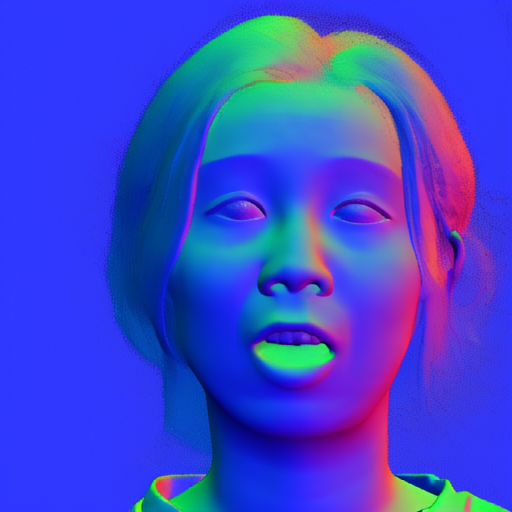

In [7]:
from PIL import Image

Image.fromarray(np.uint8(debug_views['diffusion_normal'].cpu().numpy()[0,...] * 255))

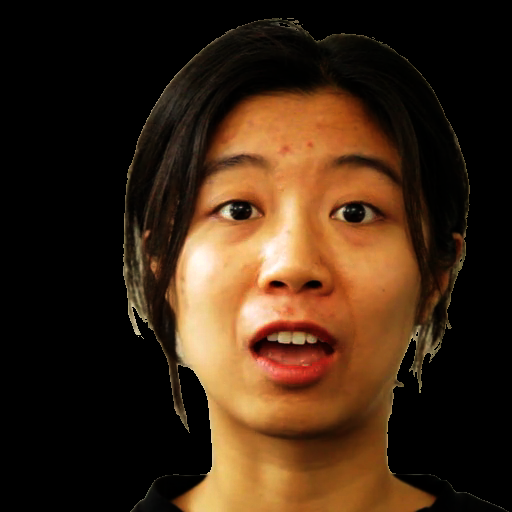

In [8]:
Image.fromarray(np.uint8(debug_views['img'].cpu().numpy()[0,...] * 255))

In [9]:
### ============== load FLAME mesh ==============================
flame_path = "/home/hleonhard/adl4cv_ws25-26_Relightable-Avatars/flare/flame/FLAME2020/generic_model.pkl"
flame_shape = dataset_train.shape_params
FLAMEServer = FLAME(flame_path, n_shape=100, n_exp=50, shape_params=flame_shape).to(device)
## ============== canonical with mouth open (jaw pose 0.4) ==============================
FLAMEServer.canonical_exp = (dataset_train.get_mean_expression()).to(device)
FLAMEServer.canonical_pose = FLAMEServer.canonical_pose.to(device)
FLAMEServer.canonical_verts, FLAMEServer.canonical_pose_feature, FLAMEServer.canonical_transformations = \
    FLAMEServer(expression_params=FLAMEServer.canonical_exp, full_pose=FLAMEServer.canonical_pose)
if config.ghostbone:
    FLAMEServer.canonical_transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).float().to(device), FLAMEServer.canonical_transformations], 1)
FLAMEServer.canonical_verts = FLAMEServer.canonical_verts.to(device)

creating the FLAME Decoder


In [10]:
run_name = config.run_name if config.run_name is not None else config.input_dir.parent.name
images_save_path, images_eval_save_path, meshes_save_path, shaders_save_path, experiment_dir = make_dirs(config, run_name, config.finetune_color)

In [11]:
print(f'Setup dirs \n{images_save_path}\n{images_eval_save_path}\n{meshes_save_path}\n{shaders_save_path}\n{experiment_dir}')

Setup dirs 
/home/hleonhard/data/flare_train_setup/out/test_1/stage_1/images
/home/hleonhard/data/flare_train_setup/out/test_1/images_evaluation
/home/hleonhard/data/flare_train_setup/out/test_1/stage_1/meshes
/home/hleonhard/data/flare_train_setup/out/test_1/stage_1/network_weights
/home/hleonhard/data/flare_train_setup/out/test_1


In [12]:
## ============== load mesh/train mesh ==============================
if config.finetune_color:
    mesh_path = experiment_dir / "stage_1" / "meshes" / f"mesh_latest.obj"
    print("loading mesh from:", mesh_path)
    flame_canonical_mesh = read_mesh(mesh_path, device=device)
    flame_canonical_mesh.compute_connectivity()
    flame_canonical_mesh.to(device)
else:
    if config.downsample:
        v_down, f_down = remesh_botsch(FLAMEServer.canonical_verts.squeeze(0).cpu().detach().numpy().astype(np.float64), 
                                                                FLAMEServer.faces_tensor.cpu().numpy().astype(np.int32), h=float(config.downsample_ratio))
        verts = np.ascontiguousarray(v_down)
        faces = np.ascontiguousarray(f_down)
        print("Downsampled:", verts.shape, faces.shape)
    else:
        verts = FLAMEServer.canonical_verts.squeeze(0)
        faces = FLAMEServer.faces_tensor
    flame_canonical_mesh: Mesh = None
    flame_canonical_mesh = Mesh(verts, faces, device=device)
    flame_canonical_mesh.compute_connectivity()
    write_mesh(Path(meshes_save_path / "init_mesh.obj"), flame_canonical_mesh.to('cpu'))

In [13]:
## ============== renderer ==============================
aabb = AABB(flame_canonical_mesh.vertices.cpu().numpy())
flame_mesh_aabb = [torch.min(flame_canonical_mesh.vertices, dim=0).values, torch.max(flame_canonical_mesh.vertices, dim=0).values]
renderer = Renderer(device=device)
renderer.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)
channels_gbuffer = ['mask', 'position', 'normal', "canonical_position"]
print("Rasterizing:", channels_gbuffer)

renderer_visualization = Renderer(device=device)
renderer_visualization.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)

Rasterizing: ['mask', 'position', 'normal', 'canonical_position']


In [14]:
# ==============================================================================================
# vertices
# ==============================================================================================
lr_vertices = config.lr_vertices
displacements = Displacement(vertices_shape=flame_canonical_mesh.vertices.shape)

displacements.to(device=device)
optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)

In [15]:
# ==============================================================================================
# deformation 
# ==============================================================================================
if config.train_deformer:
    model_path = None
    print("=="*50)
    print("Training Deformer")
else:
    print("=="*50)
    print("Loading deformer network trained in the previous stage")
    config.weight_flame_regularization = 0.0
    model_path = Path(experiment_dir / "stage_1" / "network_weights" / f"deformer_latest.pt")
    assert os.path.exists(model_path)
deformer_net = get_deformer_network(FLAMEServer, model_path=model_path, train=config.train_deformer, d_in=3, dims=config.deform_dims, 
                                       weight_norm=True, multires=0, num_exp=50, aabb=flame_mesh_aabb, ghostbone=config.ghostbone, device=device)
if config.train_deformer:
    optimizer_deformer = torch.optim.Adam(list(deformer_net.parameters()), lr=config.lr_deformer)

Training Deformer


In [16]:
# ==============================================================================================
# shading
# ==============================================================================================
lgt = light.create_env_rnd()    
disentangle_network_params = {
    "material_mlp_ch": config.material_mlp_ch,
    "light_mlp_ch": config.light_mlp_ch,
    "material_mlp_dims": config.material_mlp_dims,
    "light_mlp_dims": config.light_mlp_dims
}
# Create the optimizer for the neural shader
shader = NeuralShader(fourier_features=config.fourier_features,
                      activation=config.activation,
                      last_activation=torch.nn.Sigmoid(), 
                      disentangle_network_params=disentangle_network_params,
                      bsdf=config.bsdf,
                      aabb=flame_mesh_aabb,
                      device=device)
params = list(shader.parameters()) 
if config.weight_albedo_regularization > 0:
    from robust_loss_pytorch.adaptive import AdaptiveLossFunction
    _adaptive = AdaptiveLossFunction(num_dims=4, float_dtype=np.float32, device=device)
    params += list(_adaptive.parameters()) ## need to train it
optimizer_shader = torch.optim.Adam(params, lr=config.lr_shader)

STAGE 1: Using positional encoding (NeRF) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [128, 128, 128, 128, 128], 'light_mlp_dims': [64, 64]}


In [17]:
# ==============================================================================================
# Loss Functions
# ==============================================================================================
# Initialize the loss weights and losses
loss_weights = {
    "mask": config.weight_mask,
    "normal": config.weight_normal,
    "laplacian": config.weight_laplacian,
    "shading": config.weight_shading,
    "perceptual_loss": config.weight_perceptual_loss,
    "albedo_regularization": config.weight_albedo_regularization,
    "roughness_regularization": config.weight_roughness_regularization,
    "white_light_regularization": config.weight_white_lgt_regularization,
    "fresnel_coeff": config.weight_fresnel_coeff,
    "diffusion_normal": config.diffusion_normal,
    "diffusion_albedo": config.diffusion_albedo,
    "diffusion_roughness": config.diffusion_roughness,
    "diffusion_irradiance": config.diffusion_irradiance,
}
if config.train_deformer:
    loss_weights["flame_regularization"] = 1.0 # we use the weight directly in loss function
else:
    loss_weights["flame_regularization"] = 0.0
losses = {k: torch.tensor(0.0, device=device) for k in loss_weights}
print(loss_weights)
if loss_weights["perceptual_loss"] > 0.0:
    VGGloss = VGGPerceptualLoss().to(device) # is loaded from flare losses
print("=="*50)
shader.train()
if config.train_deformer:
    deformer_net.train()
displacements.train()
print("Batch Size:", config.batch_size)
print("=="*50)

{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.1, 'white_light_regularization': 1.0, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.01, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.01, 'diffusion_irradiance': 0.0, 'flame_regularization': 1.0}


Batch Size: 2


In [18]:
# ==============================================================================================
# util func for evaluation
# ==============================================================================================
def run(args, mesh, views, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt):
    ## ============== deform ==============================     
    shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
    eval_vertices = mesh.vertices
    batched_verts = eval_vertices.unsqueeze(0).repeat(views["img"].shape[0], 1, 1)

    _, pose_features, transformations = FLAMEServer(expression_params=views["flame_expression"], full_pose=views["flame_pose"])
    if args.ghostbone:
        transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).expand(views["img"].shape[0], -1, -1, -1).float().to(device), transformations], 1)
    deformed_vertices = FLAMEServer.forward_pts_batch(pnts_c=batched_verts, betas=views["flame_expression"], transformations=transformations, pose_feature=pose_features, 
                                        shapedirs=shapedirs, posedirs=posedirs, lbs_weights=lbs_weights, dtype=torch.float32, map2_flame_original=True)

    d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
    ## ============== Rasterize ==============================
    gbuffers = renderer.render_batch(views["camera"], deformed_vertices.contiguous(), d_normals,
                        channels=channels_gbuffer, with_antialiasing=True, 
                        canonical_v=mesh.vertices, canonical_idx=mesh.indices)
    
    ## ============== predict color ==============================
    rgb_pred, cbuffers, gbuffer_mask = shader.shade(gbuffers, views, mesh, args.finetune_color, lgt)

    return rgb_pred, gbuffers, cbuffers

In [19]:
# ==============================================================================================
# T R A I N I N G
# ==============================================================================================
epochs = (config.iterations // len(dataloader_train)) + 1
iteration = 0
progress_bar = tqdm(range(epochs))
start = time.time()
losses_history = {
    'total': [],
    'albedo_reg': [],
    'normal_reg': [],
    'roughness_reg': [],
    'irradiance_reg': [],
}
for epoch in progress_bar:
    for iter_, views_subset in enumerate(dataloader_train):
        iteration += 1
        progress_bar.set_description(desc=f'Epoch {epoch}, Iter {iteration}')
        
        # ==============================================================================================
        # upsample + remesh + reduce lr + freeze if required
        # ==============================================================================================
        if iteration in config.upsample_iterations and not config.finetune_color:
            print("=="*50)
            print("Upsampling at iteration:", iteration)
            # Upsample the mesh by remeshing the surface with half the average edge length
            e0, e1 = mesh.edges.unbind(1)
            average_edge_length = torch.linalg.norm(canonical_offset_vertices[e0] - canonical_offset_vertices[e1], dim=-1).mean()
            v_upsampled, f_upsampled = remesh_botsch(canonical_offset_vertices.cpu().detach().numpy().astype(np.float64), 
                                                    mesh.indices.cpu().numpy().astype(np.int32), h=float(average_edge_length/1.5))
            v_upsampled = np.ascontiguousarray(v_upsampled)
            f_upsampled = np.ascontiguousarray(f_upsampled)
            flame_canonical_mesh = Mesh(v_upsampled, f_upsampled, device=device)
            flame_canonical_mesh.compute_connectivity()
            print("Vertices:", v_upsampled.shape)
            print("Faces:", f_upsampled.shape)
            del v_upsampled, f_upsampled
            if iteration == config.upsample_iterations[0]:
                lr_vertices *= 0.75
                # Adjust weights and step size
                loss_weights['laplacian'] *= 4
                loss_weights['normal'] *= 4
            print("laplacian weight", loss_weights['laplacian'])
            print("normal consistency weight", loss_weights['normal'])
            print("lr vertices", lr_vertices)
            displacements.register_parameter('vertex_offsets', torch.nn.Parameter(torch.zeros(flame_canonical_mesh.vertices.shape), requires_grad=True))
            displacements.canonical_vertices = flame_canonical_mesh.vertices
            displacements.vertices_shape = flame_canonical_mesh.vertices.shape
            displacements.to(device=device)
            optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)
            print("=="*50)
        # ==============================================================================================
        # update/displace vertices
        # ==============================================================================================
        v_off = displacements()
        canonical_offset_vertices = flame_canonical_mesh.vertices + v_off
        mesh = flame_canonical_mesh.with_vertices(canonical_offset_vertices)
        # ==============================================================================================
        # deformation of canonical mesh
        # ==============================================================================================      
        shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
        
        batched_verts = mesh.vertices.unsqueeze(0).repeat(config.batch_size, 1, 1)
        _, pose_features, transformations = FLAMEServer(expression_params=views_subset["flame_expression"], full_pose=views_subset["flame_pose"])
        if config.ghostbone:
            transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).expand(config.batch_size, -1, -1, -1).float().to(device), transformations], 1)
        deformed_vertices = FLAMEServer.forward_pts_batch(pnts_c=batched_verts, betas=views_subset["flame_expression"], transformations=transformations, pose_feature=pose_features, 
                                            shapedirs=shapedirs, posedirs=posedirs, lbs_weights=lbs_weights, dtype=torch.float32, map2_flame_original=True)
        d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
        # ==============================================================================================
        # R A S T E R I Z A T I O N
        # ==============================================================================================
        gbuffers = renderer.render_batch(views_subset['camera'], deformed_vertices.contiguous(), d_normals, 
                                channels=channels_gbuffer, with_antialiasing=True, 
                                canonical_v=mesh.vertices, canonical_idx=mesh.indices) 
        
        # ==============================================================================================
        # loss function 
        # ==============================================================================================
        ## ============== geometry regularization ==============================
        losses['normal'] = normal_consistency_loss(mesh)
        losses['laplacian'] = laplacian_loss(mesh)
        ## ============== color + regularization for color ==============================
        pred_color_masked, cbuffers, gbuffer_mask = shader.shade(gbuffers, views_subset, mesh, config.finetune_color, lgt)
        losses['shading'], pred_color, tonemapped_colors = shading_loss_batch(pred_color_masked, views_subset, config.batch_size)
        losses['perceptual_loss'] = VGGloss(tonemapped_colors[0], tonemapped_colors[1], iteration)
        
        losses['mask'] = mask_loss(views_subset["mask"], gbuffer_mask)
        ## ======= regularization color ========
        losses['albedo_regularization'] = albedo_regularization(_adaptive, shader, mesh, device, displacements, iteration)
        losses['white_light_regularization'] = white_light(cbuffers)
        losses['roughness_regularization'] = roughness_regularization(cbuffers["roughness"], views_subset["skin_mask"], views_subset["mask"], r_mean=config.r_mean)
        losses["fresnel_coeff"] = spec_intensity_regularization(cbuffers["ko"], views_subset["skin_mask"], views_subset["mask"])
        
        ## ============== flame regularization ==============================
        if loss_weights['flame_regularization'] > 0:
            losses['flame_regularization'], gt_nn = flame_regularization(FLAMEServer, lbs_weights, shapedirs, posedirs, mesh.vertices, config.ghostbone, 
                                                                  iteration, config.flame_mask, views_subset=views_subset, gbuffer=gbuffers, 
                                                                  weight_lbs=config.weight_flame_regularization)
        
            if iteration in config.decay_flame:
                print("Decaying flame regularization")
                loss_weights['flame_regularization'] *= 0.5

        ## ============== diffusion regularization ==============================
        losses['diffusion_normal'] = diffusion_normal_regularization(gbuffers["normal"], views_subset["diffusion_normal"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_albedo'] = diffusion_albedo_regularization(cbuffers["albedo"], views_subset["diffusion_albedo"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_roughness'] = diffusion_roughness_regularization(cbuffers["roughness"], views_subset["diffusion_roughness"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_irradiance'] = diffusion_irradiance_regularization(cbuffers["irradiance"], views_subset["diffusion_irradiance"], views_subset["skin_mask"], views_subset["mask"])
        loss = torch.tensor(0., device=device) 
        for k, v in losses.items():
            loss += v * loss_weights[k]
        # ==============================================================================================
        # Optimizer step
        # ==============================================================================================
        optimizer_shader.zero_grad()
        optimizer_vertices.zero_grad()
        if config.train_deformer:
            optimizer_deformer.zero_grad()
        loss.backward()
        torch.cuda.synchronize()
        ### increase the gradients of positional encoding following tinycudnn
        if config.grad_scale and config.fourier_features == "hashgrid":
            shader.fourier_feature_transform.params.grad /= 8.0
        optimizer_shader.step()
        optimizer_vertices.step()
        if config.train_deformer:
            optimizer_deformer.step()
        progress_bar.set_postfix({'loss': loss.detach().cpu().item()})

        losses_history['total'].append(loss.detach().cpu().item())
        losses_history['albedo_reg'].append(losses['diffusion_albedo'].detach().cpu().item())
        losses_history['normal_reg'].append(losses['diffusion_normal'].detach().cpu().item())
        losses_history['roughness_reg'].append(losses['diffusion_roughness'].detach().cpu().item())
        losses_history['irradiance_reg'].append(losses['diffusion_irradiance'].detach().cpu().item())
        # ==============================================================================================
        # warning: check if light mlp diverged
        # ==============================================================================================
        '''
        We do not use an activation function for the output layer of light MLP because we are learning in sRGB space where the values 
        are not restricted between 0 and 1. As a result, the light MLP diverges sometimes and predicts only zero values. 
        Hence, we have included the try and catch block to automatically restart the training during this case. 
        '''
        if iteration == 300: # 100:
            convert_uint = lambda x: torch.from_numpy(np.clip(np.rint(dataset_util.rgb_to_srgb(x).detach().cpu().numpy() * 255.0), 0, 255).astype(np.uint8)).to(device)
            try:
                diffuse_shading = convert_uint(cbuffers["shading"])
                specular_shading = convert_uint(cbuffers["specu"])
                if torch.count_nonzero(diffuse_shading) == 0 or torch.count_nonzero(specular_shading) == 0:
                    raise ValueError("All values predicted from light MLP are zero")
            except ValueError as e:
                print(f"Error: {e}")
                raise  # Raise the exception to exit the current execution of main()
        
        # ==============================================================================================
        # V I S U A L I Z A T I O N S
        # ==============================================================================================
        if (config.visualization_frequency > 0) and (iteration == 1 or iteration % config.visualization_frequency == 0):
            with torch.no_grad():
                debug_rgb_pred, debug_gbuffer, debug_cbuffers = run(config, mesh, debug_views, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt)
                ## ============== visualize ==============================
                visualize_training(debug_rgb_pred, debug_cbuffers, debug_gbuffer, debug_views, images_save_path, iteration)
                del debug_gbuffer, debug_cbuffers
        ## ============== save intermediate ==============================
        if (config.save_frequency > 0) and (iteration == 1 or iteration % config.save_frequency == 0):
            with torch.no_grad():
                write_mesh(meshes_save_path / f"mesh_{iteration:06d}.obj", mesh.detach().to('cpu'))                                
                shader.save(shaders_save_path / f'shader_{iteration:06d}.pt')
                displacements.save(shaders_save_path / f'displacement_{iteration:06d}.pt')
                deformer_net.save(shaders_save_path / f'deformer_{iteration:06d}.pt')
end = time.time()
total_time = ((end - start) % 3600)
print("TIME TAKEN (mins):", int(total_time // 60))
# ==============================================================================================
# s a v e
# ==============================================================================================
with open(experiment_dir / "args.txt", "w") as text_file:
    print(f"{config}", file=text_file)
write_mesh(meshes_save_path / f"mesh_latest.obj", mesh.detach().to('cpu'))
shader.save(shaders_save_path / f'shader_latest.pt')
displacements.save(shaders_save_path / f'displacement_latest.pt')
deformer_net.save(shaders_save_path / f'deformer_latest.pt')

  0%|          | 0/2 [00:00<?, ?it/s]

Using /home/hleonhard/.cache/torch_extensions/py39_cu116 as PyTorch extensions root...
Detected CUDA files, patching ldflags
Emitting ninja build file /home/hleonhard/.cache/torch_extensions/py39_cu116/renderutils_plugin/build.ninja...
Building extension module renderutils_plugin...
Allowing ninja to set a default number of workers... (overridable by setting the environment variable MAX_JOBS=N)


ninja: no work to do.


Loading extension module renderutils_plugin...


Decaying flame regularization
Upsampling at iteration: 500
Vertices: (17921, 3)
Faces: (35802, 3)
laplacian weight 240.0
normal consistency weight 0.4
lr vertices 0.00075
TIME TAKEN (mins): 15


In [20]:
# stage 2 training
config.finetune_color = True
config.final_iter = config.iterations
config.lr_vertices = 1e-5
config.train_deformer = False
config.iterations = 1000
config.sample_idx_ratio = 1
config.fourier_features = "hashgrid"
config.material_mlp_dims = [64, 64]
config.light_mlp_dims = [64, 64]

In [21]:
run_name = config.run_name if config.run_name is not None else config.input_dir.parent.name
images_save_path, images_eval_save_path, meshes_save_path, shaders_save_path, experiment_dir = make_dirs(config, run_name, config.finetune_color)
print(f'Setup dirs \n{images_save_path}\n{images_eval_save_path}\n{meshes_save_path}\n{shaders_save_path}\n{experiment_dir}')

Setup dirs 
/home/hleonhard/data/flare_train_setup/out/test_1/stage_2/images
/home/hleonhard/data/flare_train_setup/out/test_1/images_evaluation
/home/hleonhard/data/flare_train_setup/out/test_1/stage_2/meshes
/home/hleonhard/data/flare_train_setup/out/test_1/stage_2/network_weights
/home/hleonhard/data/flare_train_setup/out/test_1


In [22]:
## ============== load mesh/train mesh ==============================
if config.finetune_color:
    mesh_path = experiment_dir / "stage_1" / "meshes" / f"mesh_latest.obj"
    print("loading mesh from:", mesh_path)
    flame_canonical_mesh = read_mesh(mesh_path, device=device)
    flame_canonical_mesh.compute_connectivity()
    flame_canonical_mesh.to(device)
else:
    if config.downsample:
        v_down, f_down = remesh_botsch(FLAMEServer.canonical_verts.squeeze(0).cpu().detach().numpy().astype(np.float64), 
                                                                FLAMEServer.faces_tensor.cpu().numpy().astype(np.int32), h=float(config.downsample_ratio))
        verts = np.ascontiguousarray(v_down)
        faces = np.ascontiguousarray(f_down)
        print("Downsampled:", verts.shape, faces.shape)
    else:
        verts = FLAMEServer.canonical_verts.squeeze(0)
        faces = FLAMEServer.faces_tensor
    flame_canonical_mesh: Mesh = None
    flame_canonical_mesh = Mesh(verts, faces, device=device)
    flame_canonical_mesh.compute_connectivity()
    write_mesh(Path(meshes_save_path / "init_mesh.obj"), flame_canonical_mesh.to('cpu'))

loading mesh from: /home/hleonhard/data/flare_train_setup/out/test_1/stage_1/meshes/mesh_latest.obj


In [23]:
## ============== renderer ==============================
aabb = AABB(flame_canonical_mesh.vertices.cpu().numpy())
flame_mesh_aabb = [torch.min(flame_canonical_mesh.vertices, dim=0).values, torch.max(flame_canonical_mesh.vertices, dim=0).values]
renderer = Renderer(device=device)
renderer.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)
channels_gbuffer = ['mask', 'position', 'normal', "canonical_position"]
print("Rasterizing:", channels_gbuffer)

renderer_visualization = Renderer(device=device)
renderer_visualization.set_near_far(dataset_train, torch.from_numpy(aabb.corners).to(device), epsilon=0.5)

Rasterizing: ['mask', 'position', 'normal', 'canonical_position']


In [24]:
# ==============================================================================================
# vertices
# ==============================================================================================
lr_vertices = config.lr_vertices
displacements = Displacement(vertices_shape=flame_canonical_mesh.vertices.shape)

displacements.to(device=device)
optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)

In [25]:
# ==============================================================================================
# deformation 
# ==============================================================================================
if config.train_deformer:
    model_path = None
    print("=="*50)
    print("Training Deformer")
else:
    print("=="*50)
    print("Loading deformer network trained in the previous stage")
    config.weight_flame_regularization = 0.0
    model_path = Path(experiment_dir / "stage_1" / "network_weights" / f"deformer_latest.pt")
    assert os.path.exists(model_path)
deformer_net = get_deformer_network(FLAMEServer, model_path=model_path, train=config.train_deformer, d_in=3, dims=config.deform_dims, 
                                       weight_norm=True, multires=0, num_exp=50, aabb=flame_mesh_aabb, ghostbone=config.ghostbone, device=device)
if config.train_deformer:
    optimizer_deformer = torch.optim.Adam(list(deformer_net.parameters()), lr=config.lr_deformer)

Loading deformer network trained in the previous stage


In [26]:
# ==============================================================================================
# shading
# ==============================================================================================
lgt = light.create_env_rnd()    
disentangle_network_params = {
    "material_mlp_ch": config.material_mlp_ch,
    "light_mlp_ch": config.light_mlp_ch,
    "material_mlp_dims": config.material_mlp_dims,
    "light_mlp_dims": config.light_mlp_dims
}
# Create the optimizer for the neural shader
shader = NeuralShader(fourier_features=config.fourier_features,
                      activation=config.activation,
                      last_activation=torch.nn.Sigmoid(), 
                      disentangle_network_params=disentangle_network_params,
                      bsdf=config.bsdf,
                      aabb=flame_mesh_aabb,
                      device=device)
params = list(shader.parameters()) 
if config.weight_albedo_regularization > 0:
    from robust_loss_pytorch.adaptive import AdaptiveLossFunction
    _adaptive = AdaptiveLossFunction(num_dims=4, float_dtype=np.float32, device=device)
    params += list(_adaptive.parameters()) ## need to train it
optimizer_shader = torch.optim.Adam(params, lr=config.lr_shader)

STAGE 2: Using hashgrid (tinycudann) for intrinsic materials
{'material_mlp_ch': 5, 'light_mlp_ch': 3, 'material_mlp_dims': [64, 64], 'light_mlp_dims': [64, 64]}


In [27]:
# ==============================================================================================
# Loss Functions
# ==============================================================================================
# Initialize the loss weights and losses
loss_weights = {
    "mask": config.weight_mask,
    "normal": config.weight_normal,
    "laplacian": config.weight_laplacian,
    "shading": config.weight_shading,
    "perceptual_loss": config.weight_perceptual_loss,
    "albedo_regularization": config.weight_albedo_regularization,
    "roughness_regularization": config.weight_roughness_regularization,
    "white_light_regularization": config.weight_white_lgt_regularization,
    "fresnel_coeff": config.weight_fresnel_coeff,
    "diffusion_normal": config.diffusion_normal,
    "diffusion_albedo": config.diffusion_albedo,
    "diffusion_roughness": config.diffusion_roughness,
    "diffusion_irradiance": config.diffusion_irradiance,
}
if config.train_deformer:
    loss_weights["flame_regularization"] = 1.0 # we use the weight directly in loss function
else:
    loss_weights["flame_regularization"] = 0.0
losses = {k: torch.tensor(0.0, device=device) for k in loss_weights}
print(loss_weights)
if loss_weights["perceptual_loss"] > 0.0:
    VGGloss = VGGPerceptualLoss().to(device) # is loaded from flare losses
print("=="*50)
shader.train()
if config.train_deformer:
    deformer_net.train()
displacements.train()
print("Batch Size:", config.batch_size)
print("=="*50)

{'mask': 2.0, 'normal': 0.1, 'laplacian': 60.0, 'shading': 1.0, 'perceptual_loss': 0.1, 'albedo_regularization': 0.01, 'roughness_regularization': 0.1, 'white_light_regularization': 1.0, 'fresnel_coeff': 0.01, 'diffusion_normal': 0.01, 'diffusion_albedo': 0.01, 'diffusion_roughness': 0.01, 'diffusion_irradiance': 0.0, 'flame_regularization': 0.0}


Batch Size: 2


In [28]:
# ==============================================================================================
# T R A I N I N G
# ==============================================================================================
epochs = (config.iterations // len(dataloader_train)) + 1
iteration = 0
progress_bar = tqdm(range(epochs))
start = time.time()
for epoch in progress_bar:
    for iter_, views_subset in enumerate(dataloader_train):
        iteration += 1
        progress_bar.set_description(desc=f'Epoch {epoch}, Iter {iteration}')
        
        # ==============================================================================================
        # upsample + remesh + reduce lr + freeze if required
        # ==============================================================================================
        if iteration in config.upsample_iterations and not config.finetune_color:
            print("=="*50)
            print("Upsampling at iteration:", iteration)
            # Upsample the mesh by remeshing the surface with half the average edge length
            e0, e1 = mesh.edges.unbind(1)
            average_edge_length = torch.linalg.norm(canonical_offset_vertices[e0] - canonical_offset_vertices[e1], dim=-1).mean()
            v_upsampled, f_upsampled = remesh_botsch(canonical_offset_vertices.cpu().detach().numpy().astype(np.float64), 
                                                    mesh.indices.cpu().numpy().astype(np.int32), h=float(average_edge_length/1.5))
            v_upsampled = np.ascontiguousarray(v_upsampled)
            f_upsampled = np.ascontiguousarray(f_upsampled)
            flame_canonical_mesh = Mesh(v_upsampled, f_upsampled, device=device)
            flame_canonical_mesh.compute_connectivity()
            print("Vertices:", v_upsampled.shape)
            print("Faces:", f_upsampled.shape)
            del v_upsampled, f_upsampled
            if iteration == config.upsample_iterations[0]:
                lr_vertices *= 0.75
                # Adjust weights and step size
                loss_weights['laplacian'] *= 4
                loss_weights['normal'] *= 4
            print("laplacian weight", loss_weights['laplacian'])
            print("normal consistency weight", loss_weights['normal'])
            print("lr vertices", lr_vertices)
            displacements.register_parameter('vertex_offsets', torch.nn.Parameter(torch.zeros(flame_canonical_mesh.vertices.shape), requires_grad=True))
            displacements.canonical_vertices = flame_canonical_mesh.vertices
            displacements.vertices_shape = flame_canonical_mesh.vertices.shape
            displacements.to(device=device)
            optimizer_vertices = torch.optim.Adam(list(displacements.parameters()), lr=lr_vertices)
            print("=="*50)
        # ==============================================================================================
        # update/displace vertices
        # ==============================================================================================
        v_off = displacements()
        canonical_offset_vertices = flame_canonical_mesh.vertices + v_off
        mesh = flame_canonical_mesh.with_vertices(canonical_offset_vertices)
        # ==============================================================================================
        # deformation of canonical mesh
        # ==============================================================================================      
        shapedirs, posedirs, lbs_weights = deformer_net.query_weights(mesh.vertices)
        
        batched_verts = mesh.vertices.unsqueeze(0).repeat(config.batch_size, 1, 1)
        _, pose_features, transformations = FLAMEServer(expression_params=views_subset["flame_expression"], full_pose=views_subset["flame_pose"])
        if config.ghostbone:
            transformations = torch.cat([torch.eye(4).unsqueeze(0).unsqueeze(0).expand(config.batch_size, -1, -1, -1).float().to(device), transformations], 1)
        deformed_vertices = FLAMEServer.forward_pts_batch(pnts_c=batched_verts, betas=views_subset["flame_expression"], transformations=transformations, pose_feature=pose_features, 
                                            shapedirs=shapedirs, posedirs=posedirs, lbs_weights=lbs_weights, dtype=torch.float32, map2_flame_original=True)
        d_normals = mesh.fetch_all_normals(deformed_vertices, mesh)
        # ==============================================================================================
        # R A S T E R I Z A T I O N
        # ==============================================================================================
        gbuffers = renderer.render_batch(views_subset['camera'], deformed_vertices.contiguous(), d_normals, 
                                channels=channels_gbuffer, with_antialiasing=True, 
                                canonical_v=mesh.vertices, canonical_idx=mesh.indices) 
        
        # ==============================================================================================
        # loss function 
        # ==============================================================================================
        ## ============== geometry regularization ==============================
        losses['normal'] = normal_consistency_loss(mesh)
        losses['laplacian'] = laplacian_loss(mesh)
        ## ============== color + regularization for color ==============================
        pred_color_masked, cbuffers, gbuffer_mask = shader.shade(gbuffers, views_subset, mesh, config.finetune_color, lgt)
        losses['shading'], pred_color, tonemapped_colors = shading_loss_batch(pred_color_masked, views_subset, config.batch_size)
        losses['perceptual_loss'] = VGGloss(tonemapped_colors[0], tonemapped_colors[1], iteration)
        
        losses['mask'] = mask_loss(views_subset["mask"], gbuffer_mask)
        ## ======= regularization color ========
        losses['albedo_regularization'] = albedo_regularization(_adaptive, shader, mesh, device, displacements, iteration)
        losses['white_light_regularization'] = white_light(cbuffers)
        losses['roughness_regularization'] = roughness_regularization(cbuffers["roughness"], views_subset["skin_mask"], views_subset["mask"], r_mean=config.r_mean)
        losses["fresnel_coeff"] = spec_intensity_regularization(cbuffers["ko"], views_subset["skin_mask"], views_subset["mask"])
        
        ## ============== flame regularization ==============================
        if loss_weights['flame_regularization'] > 0:
            losses['flame_regularization'], gt_nn = flame_regularization(FLAMEServer, lbs_weights, shapedirs, posedirs, mesh.vertices, config.ghostbone, 
                                                                  iteration, config.flame_mask, views_subset=views_subset, gbuffer=gbuffers, 
                                                                  weight_lbs=config.weight_flame_regularization)
        
            if iteration in config.decay_flame:
                print("Decaying flame regularization")
                loss_weights['flame_regularization'] *= 0.5

        ## ============== diffusion regularization ==============================
        losses['diffusion_normal'] = diffusion_normal_regularization(gbuffers["normal"], views_subset["diffusion_normal"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_albedo'] = diffusion_albedo_regularization(cbuffers["albedo"], views_subset["diffusion_albedo"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_roughness'] = diffusion_roughness_regularization(cbuffers["roughness"], views_subset["diffusion_roughness"], views_subset["skin_mask"], views_subset["mask"])
        losses['diffusion_irradiance'] = diffusion_irradiance_regularization(cbuffers["irradiance"], views_subset["diffusion_irradiance"], views_subset["skin_mask"], views_subset["mask"])
        loss = torch.tensor(0., device=device) 
        for k, v in losses.items():
            loss += v * loss_weights[k]
        # ==============================================================================================
        # Optimizer step
        # ==============================================================================================
        optimizer_shader.zero_grad()
        optimizer_vertices.zero_grad()
        if config.train_deformer:
            optimizer_deformer.zero_grad()
        loss.backward()
        torch.cuda.synchronize()
        ### increase the gradients of positional encoding following tinycudnn
        if config.grad_scale and config.fourier_features == "hashgrid":
            shader.fourier_feature_transform.params.grad /= 8.0
        optimizer_shader.step()
        optimizer_vertices.step()
        if config.train_deformer:
            optimizer_deformer.step()
        progress_bar.set_postfix({'loss': loss.detach().cpu().item()})

        losses_history['total'].append(loss.detach().cpu().item())
        losses_history['albedo_reg'].append(losses['diffusion_albedo'].detach().cpu().item())
        losses_history['normal_reg'].append(losses['diffusion_normal'].detach().cpu().item())
        losses_history['roughness_reg'].append(losses['diffusion_roughness'].detach().cpu().item())
        losses_history['irradiance_reg'].append(losses['diffusion_irradiance'].detach().cpu().item())
        # ==============================================================================================
        # warning: check if light mlp diverged
        # ==============================================================================================
        '''
        We do not use an activation function for the output layer of light MLP because we are learning in sRGB space where the values 
        are not restricted between 0 and 1. As a result, the light MLP diverges sometimes and predicts only zero values. 
        Hence, we have included the try and catch block to automatically restart the training during this case. 
        '''
        if iteration == 100:
            convert_uint = lambda x: torch.from_numpy(np.clip(np.rint(dataset_util.rgb_to_srgb(x).detach().cpu().numpy() * 255.0), 0, 255).astype(np.uint8)).to(device)
            try:
                diffuse_shading = convert_uint(cbuffers["shading"])
                specular_shading = convert_uint(cbuffers["specu"])
                if torch.count_nonzero(diffuse_shading) == 0 or torch.count_nonzero(specular_shading) == 0:
                    raise ValueError("All values predicted from light MLP are zero")
            except ValueError as e:
                print(f"Error: {e}")
                raise  # Raise the exception to exit the current execution of main()
        
        # ==============================================================================================
        # V I S U A L I Z A T I O N S
        # ==============================================================================================
        if (config.visualization_frequency > 0) and (iteration == 1 or iteration % config.visualization_frequency == 0):
            with torch.no_grad():
                debug_rgb_pred, debug_gbuffer, debug_cbuffers = run(config, mesh, debug_views, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, lgt)
                ## ============== visualize ==============================
                visualize_training(debug_rgb_pred, debug_cbuffers, debug_gbuffer, debug_views, images_save_path, iteration)
                del debug_gbuffer, debug_cbuffers
        ## ============== save intermediate ==============================
        if (config.save_frequency > 0) and (iteration == 1 or iteration % config.save_frequency == 0):
            with torch.no_grad():
                write_mesh(meshes_save_path / f"mesh_{iteration:06d}.obj", mesh.detach().to('cpu'))                                
                shader.save(shaders_save_path / f'shader_{iteration:06d}.pt')
                displacements.save(shaders_save_path / f'displacement_{iteration:06d}.pt')
                deformer_net.save(shaders_save_path / f'deformer_{iteration:06d}.pt')
end = time.time()
total_time = ((end - start) % 3600)
print("TIME TAKEN (mins):", int(total_time // 60))
# ==============================================================================================
# s a v e
# ==============================================================================================
with open(experiment_dir / "args.txt", "w") as text_file:
    print(f"{config}", file=text_file)
write_mesh(meshes_save_path / f"mesh_latest.obj", mesh.detach().to('cpu'))
shader.save(shaders_save_path / f'shader_latest.pt')
displacements.save(shaders_save_path / f'displacement_latest.pt')
deformer_net.save(shaders_save_path / f'deformer_latest.pt')

  0%|          | 0/1 [00:00<?, ?it/s]

TIME TAKEN (mins): 7


Saved figure to: /home/hleonhard/data/flare_train_setup/out/test_1/training_losses.png


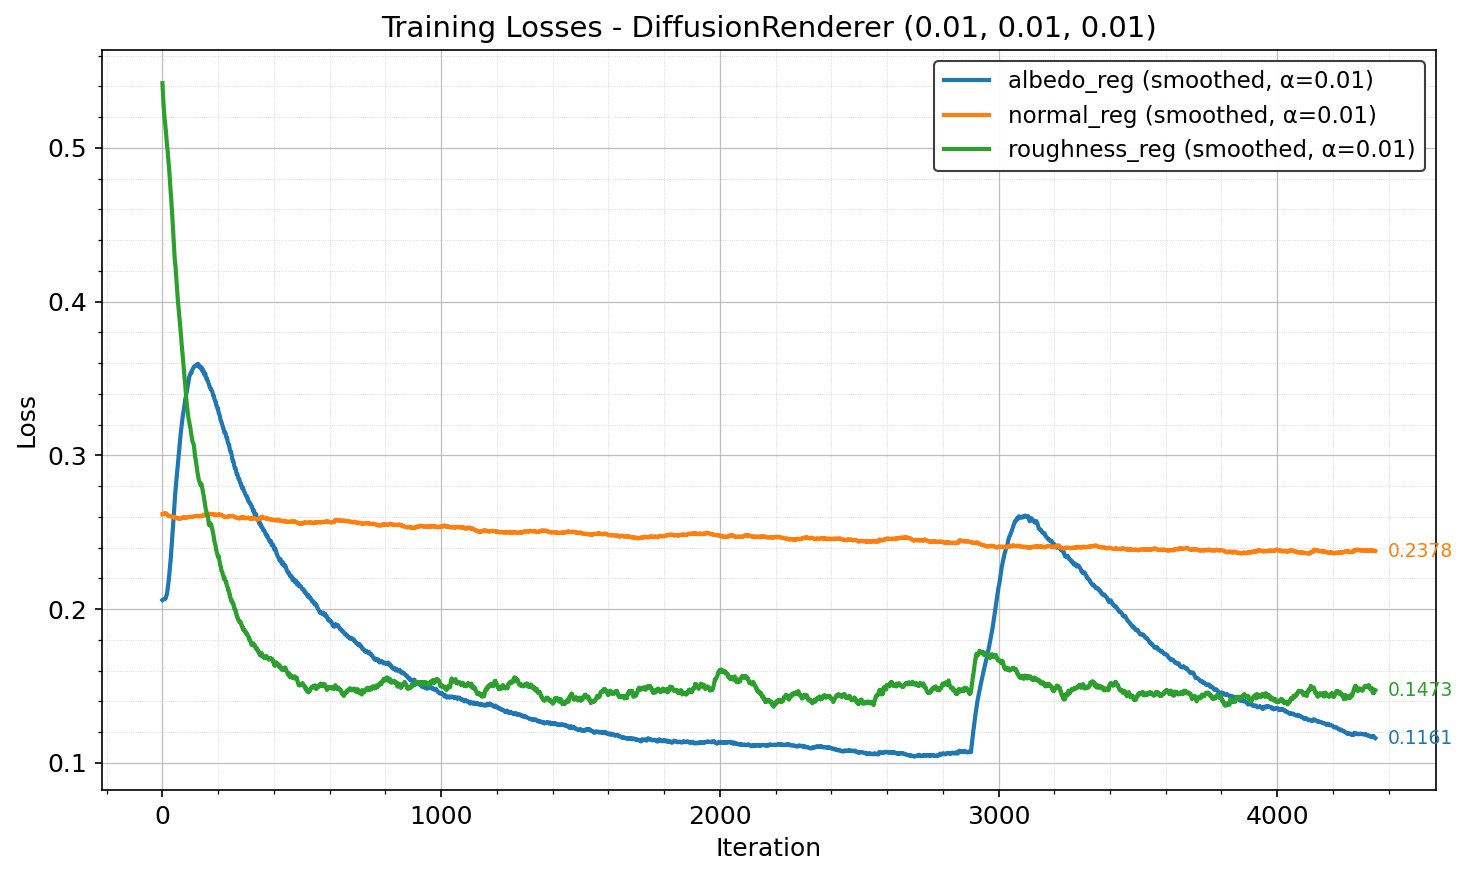

In [29]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter
import warnings

def _to_numpy(x):
    """Convert list/torch/tensor-like to numpy 1D array."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x).flatten()

def ema(signal, alpha):
    """Exponential moving average smoothing. alpha in (0,1], higher = more smoothing."""
    if alpha <= 0:
        return signal
    out = np.empty_like(signal, dtype=float)
    out[0] = signal[0]
    for i in range(1, len(signal)):
        out[i] = alpha * signal[i] + (1 - alpha) * out[i-1]
    return out

def plot_losses(
    losses_history,
    keys=None,
    figsize=(10, 6),
    dpi=150,
    smoothing_alpha=0.0,   # 0 -> no smoothing, 0.1..0.3 typical
    show_raw=False,        # If True, plot raw + smoothed (when smoothing_alpha>0)
    log_scale=False,
    title=None,
    xlabel='Iteration',
    ylabel='Loss',
    ylim=None,
    legend_loc='best',
    linewidth=2.0,
    markers=None,
    save_path=None,
    fontsize=12
):
    """
    Plot training losses from a dictionary `losses_history`.
    losses_history is expected to be a dict mapping string keys to lists/arrays of loss values, e.g.:
        {
            'total': [...],
            'albedo_reg': [...],
            'normal_reg': [...],
            'roughness_reg': [...],
            'irradiance_reg': [...],
        }

    Parameters:
    - keys: list of keys to plot, in desired order. If None, all keys in dict are plotted in insertion order.
    - smoothing_alpha: float in [0,1]. If > 0, an EMA-smoothed curve is plotted.
    - show_raw: if True and smoothing_alpha>0, both raw and smoothed are shown.
    - log_scale: if True, y-axis is displayed logarithmically.
    - save_path: if provided, figure is saved to this path (png/pdf supported).
    """
    if not isinstance(losses_history, dict):
        raise ValueError("losses_history must be a dict of lists/arrays.")

    # Default keys to all in the dict if not specified
    if keys is None:
        keys = list(losses_history.keys())

    # Setup figure style
    plt.rcParams.update({
        "figure.figsize": figsize,
        "figure.dpi": dpi,
        "font.size": fontsize,
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.edgecolor": "0.2"
    })
    fig, ax = plt.subplots()

    # Color/marker cycles
    color_cycle = plt.rcParams['axes.prop_cycle'].by_key().get('color', None)
    n_colors = len(color_cycle) if color_cycle is not None else None
    if markers is None:
        markers = [None] * len(keys)

    plotted_any = False
    for i, key in enumerate(keys):
        if key not in losses_history:
            warnings.warn(f"Key '{key}' not found in losses_history — skipping.")
            continue

        y = _to_numpy(losses_history[key])
        if y.size == 0:
            warnings.warn(f"Key '{key}' contains no data — skipping.")
            continue

        x = np.arange(len(y))
        # Choose color/marker
        color = color_cycle[i % n_colors] if (color_cycle and n_colors) else None
        marker = markers[i] if i < len(markers) else None

        if smoothing_alpha > 0:
            y_s = ema(y, smoothing_alpha)
            if show_raw:
                ax.plot(x, y, linestyle='--', linewidth=max(0.8, linewidth*0.8),
                        alpha=0.6, label=f"{key} (raw)", color=color, marker=marker, markersize=4)
            ax.plot(x, y_s, linewidth=linewidth, label=f"{key} (smoothed, α={smoothing_alpha})",
                    color=color)
            last_val = y_s[-1]
        else:
            ax.plot(x, y, linewidth=linewidth, label=key, color=color, marker=marker, markersize=4)
            last_val = y[-1]

        # Add small text annotation at the end of the curve (avoids overlap by small x-offset)
        try:
            ax.annotate(f"{last_val:.4g}", xy=(x[-1], last_val),
                        xytext=(6, 0), textcoords='offset points', va='center', fontsize=9, color=color)
        except Exception:
            # in case annotate fails for strange reasons, ignore
            pass

        plotted_any = True

    if not plotted_any:
        raise RuntimeError("No valid losses were plotted. Check your keys / losses_history content.")

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title, fontsize=fontsize+2)

    if log_scale:
        ax.set_yscale('log')
        # better formatting for log scale
        ax.yaxis.set_major_formatter(ScalarFormatter())
        ax.yaxis.set_minor_formatter(ScalarFormatter())

    if ylim is not None:
        ax.set_ylim(ylim)

    ax.grid(which='major', linestyle='-', linewidth=0.6, alpha=0.8)
    ax.grid(which='minor', linestyle=':', linewidth=0.4, alpha=0.6)
    ax.minorticks_on()

    # Tight legend with a small title showing final values summary
    ax.legend(loc=legend_loc, fontsize=max(8, fontsize-1), framealpha=0.95)

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
        print(f"Saved figure to: {save_path}")

    plt.show()


plot_losses(
    losses_history,
    keys=['albedo_reg', 'normal_reg', 'roughness_reg'],# 'irradiance_reg'],
    smoothing_alpha=0.01,   # set to 0 for no smoothing
    show_raw=False,
    log_scale=False,
    title="Training Losses - DiffusionRenderer (0.01, 0.01, 0.01)",
    save_path=f'{experiment_dir.__str__()}/training_losses.png'
)


In [30]:
# ==============================================================================================
# FINAL: qualitative and quantitative results
# ==============================================================================================
from flare.utils import save_individual_img


def quantitative_eval(args, mesh, dataloader_validate, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer,
                        experiment_dir, images_eval_save_path, lgt=None, save_each=False):

    for it, views_subset in enumerate(dataloader_validate):
        with torch.no_grad():
            rgb_pred, gbuffer, cbuffer = run(args, mesh, views_subset, FLAMEServer, deformer_net, shader, renderer, device, 
                    channels_gbuffer, lgt=lgt)

        rgb_pred = rgb_pred * gbuffer["mask"]
        if save_each:
            save_individual_img(rgb_pred, views_subset, gbuffer["normal"], gbuffer["mask"], cbuffer, images_eval_save_path, iteration=None)
    print(f'Created all images in {images_eval_save_path}')
    ## ============== metrics ==============================
    gt_dir = Path(args.input_dir)
    if gt_dir is not None:
        eval_list = metrics.run(images_eval_save_path, gt_dir, args.eval_dir)

    with open(str(experiment_dir / "final_eval.txt"), 'a') as f:
        f.writelines("\n"+"w/o cloth result:"+"\n")
        f.writelines("\n"+"MAE | LPIPS | SSIM | PSNR"+"\n")
        if gt_dir is not None:
            eval_list = [str(e) for e in eval_list]
            f.writelines(" ".join(eval_list))

if config.finetune_color:        
    ## ============== free memory before evaluation ==============================
    del dataset_train, dataloader_train, debug_views, views_subset
    print("=="*50)
    print("E V A L U A T I O N")
    print("=="*50)
    dataset_val = DatasetLoader(config, train_dir=config.eval_dir, sample_ratio=1, pre_load=True)
    dataloader_validate = torch.utils.data.DataLoader(dataset_val, batch_size=4, collate_fn=dataset_val.collate)
    quantitative_eval(config, mesh, dataloader_validate, FLAMEServer, deformer_net, shader, renderer, device, channels_gbuffer, experiment_dir
                    , images_eval_save_path / "qualitative_results", lgt=lgt, save_each=True)

E V A L U A T I O N
loaded 1824 views
Created all images in /home/hleonhard/data/flare_train_setup/out/diff_renderer_05_05_05_0/images_evaluation/qualitative_results
rgb
image index start from:  1
['1791', '1473', '499', '543', '115', '1686', '710', '167', '310', '1482', '1467', '882', '1364', '904', '735', '885', '1560', '211', '1714', '1172', '156', '89', '1134', '588', '104', '1080', '894', '1752', '1269', '1083', '1630', '1672', '675', '1487', '1405', '739', '871', '294', '627', '733', '1014', '23', '1521', '434', '317', '1579', '1812', '1675', '1444', '173', '1137', '1709', '1626', '707', '10', '624', '1210', '446', '1085', '1428', '1734', '886', '1494', '1347', '1737', '1776', '1251', '1326', '1437', '1522', '1407', '1304', '1638', '231', '965', '1076', '1021', '19', '487', '21', '1561', '972', '838', '1742', '1383', '616', '509', '309', '1376', '683', '681', '137', '797', '1271', '1392', '336', '577', '836', '1597', '768', '1352', '117', '1550', '523', '464', '605', '498', '568'

  0%|          | 0/1823 [00:00<?, ?it/s]

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


[ WARN:0@1924.678] global loadsave.cpp:848 imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.
/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3504: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/hleonhard/mini

Loading model from: /home/hleonhard/miniconda3/envs/flare/lib/python3.9/site-packages/lpips/weights/v0.1/alex.pth
nan	nan	nan	nan	nan


...

0.027413517313543707	0.10155431839637458	0.8536703015118837	23.954466869831084	nan


 99%|█████████▉| 1802/1823 [02:59<00:02, 10.16it/s]

0.027370758219104674	0.10136438648319906	0.8537784429722363	23.966315223905774	nan


100%|██████████| 1823/1823 [03:01<00:00, 10.03it/s]

Written result to  /home/hleonhard/data/flare_train_setup/out/diff_renderer_05_05_05_0/images_evaluation/qualitative_results/results_no_cloth_rgb.npz
0.02735154945004856	0.10131596554800239	0.85381739082666	23.971246229706395


In [31]:
data = np.load(images_eval_save_path / "qualitative_results" / "results_no_cloth_rgb.npz")

lst = data.files
for item in lst:
    print(item)
    print(data[item])
    if item in ["l1_l", "perceptual_l", "ssim_l", "psnr_l"]:
        print(f"Mean {item}: {np.mean(data[item])}")
    if item == 'filenames':
        print(f"Evalauted a total of {len(data[item])} points")

subfolders
['MVI_1812' 'MVI_1812' 'MVI_1812' ... 'MVI_1812' 'MVI_1812' 'MVI_1812']
filenames
['1791.png' '1473.png' '499.png' ... '1004.png' '655.png' '1061.png']
Evalauted a total of 1823 points
mse_l
[0.00287617 0.00404308 0.00307107 ... 0.00349172 0.00436573 0.00357853]
rmse_l
[0.05362997 0.06358524 0.05541725 ... 0.0590908  0.06607369 0.05982084]
mae_l
[0.02166221 0.02671759 0.02307484 ... 0.0246706  0.02800602 0.02456495]
perceptual_l
[0.08319833 0.10206302 0.09810258 ... 0.09135521 0.08917046 0.10266744]
Mean perceptual_l: 0.10131596554800239
ssim_l
[0.87159866 0.85338467 0.86008221 ... 0.86645144 0.85039914 0.8582738 ]
Mean ssim_l: 0.85381739082666
psnr_l
[25.41184616 23.93287277 25.12709808 ... 24.56959915 23.59942627
 24.46294785]
Mean psnr_l: 23.971246229706395
l1_l
[0.00287617 0.00404308 0.00307107 ... 0.00349172 0.00436573 0.00357853]
Mean l1_l: 0.0042671085172090156


In [41]:
import glob
import contextlib
from PIL import Image
import functools

grid1_path = experiment_dir / "stage_1" / "images" / "grid" / "grid_*.png"
grid2_path = experiment_dir / "stage_2" / "images" / "grid" / "grid_*.png"
length = 3 + len(grid1_path.__str__())

def sorter(x, y):
    if 'stage_1' in x and 'stage_1' not in y:
        return True
    if 'stage_1' in y and 'stage_1' not in x:
        return False
    else:
        return int(x[(length-len(x)-8):-4]) - int(y[(length-len(y)-8):-4])

files_in = sorted(glob.glob(grid1_path.__str__()) + glob.glob(grid2_path.__str__()), key=functools.cmp_to_key(sorter))
fp_out = experiment_dir / f"training_rgbx_1_1_1_1.gif"
# use exit stack to automatically close opened images
with contextlib.ExitStack() as stack:
    # lazily load images
    imgs = (stack.enter_context(Image.open(f)) for f in files_in)
    img = next(imgs)
    # https://pillow.readthedocs.io/en/stable/handbook/image-file-formats.html#gif
    img.save(fp=fp_out.__str__(), format='GIF', append_images=imgs,
             save_all=True, duration=200, loop=0)

In [42]:
experiment_dir

PosixPath('/home/hleonhard/data/flare_train_setup/out/rgbx_1_1_1_1')